In [1]:
"""
Installation and Setup
Run this first to install all required packages
"""

# Install required packages
!pip install transformers datasets torch evaluate scikit-learn peft accelerate -q

# Verify installations
import transformers
import datasets
import torch
print(f"Transformers version: {transformers.__version__}")
print(f"Datasets version: {datasets.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00
Transformers version: 4.57.6
Datasets version: 4.0.0
PyTorch version: 2.9.0+cu126
CUDA available: True
CUDA device: Tesla T4


In [2]:
"""
Import Required Libraries
"""

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import (
    GPT2Tokenizer,
    GPT2ForSequenceClassification,
    GPT2Config,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType
import evaluate
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
"""
Load and Prepare Dataset
Change 'sst2' to your chosen GLUE task if different
"""

# Load GLUE dataset (using SST-2 as example)
TASK_NAME = "sst2"  # Change this to your task: "cola", "mnli", "qnli", "qqp", etc.

print(f"Loading GLUE task: {TASK_NAME}")
dataset = load_dataset("glue", TASK_NAME)

# Display dataset info
print(f"\nDataset structure:")
print(dataset)

print(f"\nTrain size: {len(dataset['train'])}")
print(f"Validation size: {len(dataset['validation'])}")

# Show sample
print(f"\nSample from training set:")
print(dataset['train'][0])

# Get number of labels
if TASK_NAME == "sst2":
    num_labels = 2
elif TASK_NAME == "cola":
    num_labels = 2
elif TASK_NAME == "mnli":
    num_labels = 3
elif TASK_NAME == "qnli":
    num_labels = 2
elif TASK_NAME == "qqp":
    num_labels = 2
else:
    num_labels = 2  # default

print(f"\nNumber of labels: {num_labels}")

# Check label distribution
from collections import Counter
train_labels = dataset['train']['label']
print(f"\nLabel distribution in training set:")
print(Counter(train_labels))

Loading GLUE task: sst2


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]


Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1821
    })
})

Train size: 67349
Validation size: 872

Sample from training set:
{'sentence': 'hide new secretions from the parental units ', 'label': 0, 'idx': 0}

Number of labels: 2

Label distribution in training set:
Counter({1: 37569, 0: 29780})


In [4]:
"""
Prepare Your 20 Selected Instances
Replace these with your actual selected instances from Deliverable 1
"""

# Replace these with your actual 10 easy + 10 difficult instances
# Format: (text, label, difficulty)

selected_instances = [
    # Easy instances (indices 0-9)
    {"idx": 0, "sentence": "This is a terrible movie.", "label": 0, "difficulty": "easy"},
    {"idx": 1, "sentence": "Absolutely brilliant!", "label": 1, "difficulty": "easy"},
    {"idx": 2, "sentence": "I loved every minute of it.", "label": 1, "difficulty": "easy"},
    {"idx": 3, "sentence": "Boring and predictable.", "label": 0, "difficulty": "easy"},
    {"idx": 4, "sentence": "A complete waste of time.", "label": 0, "difficulty": "easy"},
    {"idx": 5, "sentence": "The best film of the year.", "label": 1, "difficulty": "easy"},
    {"idx": 6, "sentence": "Horribly acted.", "label": 0, "difficulty": "easy"},
    {"idx": 7, "sentence": "Wonderfully entertaining.", "label": 1, "difficulty": "easy"},
    {"idx": 8, "sentence": "Total disappointment.", "label": 0, "difficulty": "easy"},
    {"idx": 9, "sentence": "Fantastic performances.", "label": 1, "difficulty": "easy"},

    # Difficult instances (indices 10-19)
    {"idx": 10, "sentence": "Not the worst movie I've seen.", "label": 0, "difficulty": "difficult"},
    {"idx": 11, "sentence": "It's so bad it's good.", "label": 1, "difficulty": "difficult"},
    {"idx": 12, "sentence": "The first half was great, but the ending ruined it.", "label": 0, "difficulty": "difficult"},
    {"idx": 13, "sentence": "Could have been better.", "label": 0, "difficulty": "difficult"},
    {"idx": 14, "sentence": "I expected more from this director.", "label": 0, "difficulty": "difficult"},
    {"idx": 15, "sentence": "Nothing special, just okay.", "label": 0, "difficulty": "difficult"},
    {"idx": 16, "sentence": "Fails to live up to the hype.", "label": 0, "difficulty": "difficult"},
    {"idx": 17, "sentence": "Not without its charms.", "label": 1, "difficulty": "difficult"},
    {"idx": 18, "sentence": "Better than average, but still mediocre.", "label": 0, "difficulty": "difficult"},
    {"idx": 19, "sentence": "A guilty pleasure.", "label": 1, "difficulty": "difficult"},
]

# Convert to DataFrame for easier handling
selected_df = pd.DataFrame(selected_instances)
print("Selected instances:")
print(selected_df)

print(f"\nEasy instances: {len(selected_df[selected_df['difficulty'] == 'easy'])}")
print(f"Difficult instances: {len(selected_df[selected_df['difficulty'] == 'difficult'])}")

Selected instances:
    idx                                           sentence  label difficulty
0     0                          This is a terrible movie.      0       easy
1     1                              Absolutely brilliant!      1       easy
2     2                        I loved every minute of it.      1       easy
3     3                            Boring and predictable.      0       easy
4     4                          A complete waste of time.      0       easy
5     5                         The best film of the year.      1       easy
6     6                                    Horribly acted.      0       easy
7     7                          Wonderfully entertaining.      1       easy
8     8                              Total disappointment.      0       easy
9     9                            Fantastic performances.      1       easy
10   10                     Not the worst movie I've seen.      0  difficult
11   11                             It's so bad it's goo

In [5]:
"""
BLOCK 5: Tokenization
Prepare the data for GPT-2
"""

# Load tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

# GPT-2 doesn't have a pad token by default, so we add one
tokenizer.pad_token = tokenizer.eos_token

print(f"Vocabulary size: {len(tokenizer)}")
print(f"Pad token: {tokenizer.pad_token}")
print(f"EOS token: {tokenizer.eos_token}")

# Tokenization function
def tokenize_function(examples):
    # For SST-2, we have a 'sentence' field
    # Adjust this based on your task
    if 'sentence' in examples:
        return tokenizer(examples['sentence'], truncation=True, padding='max_length', max_length=128)
    elif 'sentence1' in examples and 'sentence2' in examples:
        # For tasks with sentence pairs (e.g., MNLI, QQP)
        return tokenizer(examples['sentence1'], examples['sentence2'],
                        truncation=True, padding='max_length', max_length=128)
    else:
        raise ValueError("Unknown dataset format")

# Tokenize datasets
print("\nTokenizing datasets...")
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# Prepare for training
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("\nTokenized dataset structure:")
print(tokenized_datasets)

# Show tokenized example
print("\nExample tokenized input:")
print(f"Input IDs shape: {tokenized_datasets['train'][0]['input_ids'].shape}")
print(f"First few tokens: {tokenized_datasets['train'][0]['input_ids'][:10]}")
print(f"Decoded: {tokenizer.decode(tokenized_datasets['train'][0]['input_ids'][:50])}")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

Vocabulary size: 50257
Pad token: <|endoftext|>
EOS token: <|endoftext|>

Tokenizing datasets...


Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]


Tokenized dataset structure:
DatasetDict({
    train: Dataset({
        features: ['sentence', 'labels', 'idx', 'input_ids', 'attention_mask'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['sentence', 'labels', 'idx', 'input_ids', 'attention_mask'],
        num_rows: 872
    })
    test: Dataset({
        features: ['sentence', 'labels', 'idx', 'input_ids', 'attention_mask'],
        num_rows: 1821
    })
})

Example tokenized input:
Input IDs shape: torch.Size([128])
First few tokens: tensor([24717,   649,  3200,   507,   422,   262, 21694,  4991,   220, 50256])
Decoded: hide new secretions from the parental units <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endof

In [6]:
"""
BLOCK 6: Setup Training Configuration
"""

# Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    save_total_limit=2,
    report_to="none",  # Disable wandb/tensorboard
    seed=42,
)

print("Training configuration:")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Output directory: {training_args.output_dir}")

# Metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    return {"accuracy": accuracy}

print("\nMetrics function defined.")

Training configuration:
  Batch size: 8
  Learning rate: 2e-05
  Epochs: 1
  Output directory: ./results

Metrics function defined.


In [7]:
"""
BLOCK 7: Variant 1 - Standard Fine-tuning (Pre-trained GPT-2)
Fine-tune all parameters of pre-trained GPT-2
"""

print("=" * 60)
print("VARIANT 1: Standard Fine-tuning (Pre-trained GPT-2)")
print("=" * 60)

# Load pre-trained GPT-2 model
model_pretrained = GPT2ForSequenceClassification.from_pretrained(
    'gpt2',
    num_labels=num_labels,
    pad_token_id=tokenizer.eos_token_id
)

# Resize token embeddings if needed
model_pretrained.resize_token_embeddings(len(tokenizer))

# Configure the model for classification
model_pretrained.config.pad_token_id = tokenizer.pad_token_id

print(f"\nModel loaded: GPT-2")
print(f"Total parameters: {sum(p.numel() for p in model_pretrained.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model_pretrained.parameters() if p.requires_grad):,}")

# Create Trainer
trainer_pretrained = Trainer(
    model=model_pretrained,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

print("\nStarting training...")
# Train the model
train_result_pretrained = trainer_pretrained.train()

print("\nTraining completed!")
print(f"Training loss: {train_result_pretrained.training_loss:.4f}")

# Evaluate
print("\nEvaluating on validation set...")
eval_result_pretrained = trainer_pretrained.evaluate()
print(f"Validation accuracy: {eval_result_pretrained['eval_accuracy']:.4f}")

# Save results
results_pretrained = {
    "variant": "standard_pretrained",
    "train_loss": train_result_pretrained.training_loss,
    "eval_accuracy": eval_result_pretrained['eval_accuracy'],
    "eval_loss": eval_result_pretrained['eval_loss']
}

print("\n" + "=" * 60)
print(f"VARIANT 1 RESULTS:")
print(f"  Validation Accuracy: {results_pretrained['eval_accuracy']:.4f}")
print(f"  Validation Loss: {results_pretrained['eval_loss']:.4f}")
print("=" * 60)

VARIANT 1: Standard Fine-tuning (Pre-trained GPT-2)


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model loaded: GPT-2
Total parameters: 124,441,344
Trainable parameters: 124,441,344

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.257500,0.319184,0.919725



Training completed!
Training loss: 0.3254

Evaluating on validation set...


Validation accuracy: 0.9197

VARIANT 1 RESULTS:
  Validation Accuracy: 0.9197
  Validation Loss: 0.3192


In [8]:
"""
BLOCK 8: Variant 2 - Random Initialization (No Pre-training)
Train GPT-2 from scratch (randomly initialized)
"""

print("=" * 60)
print("VARIANT 2: Random Initialization (No Pre-training)")
print("=" * 60)

# Create GPT-2 config
config = GPT2Config(
    vocab_size=len(tokenizer),
    n_positions=1024,
    n_ctx=1024,
    n_embd=768,
    n_layer=12,
    n_head=12,
    num_labels=num_labels,
    pad_token_id=tokenizer.pad_token_id
)

# Initialize model with random weights
model_random = GPT2ForSequenceClassification(config)

print(f"\nModel initialized: GPT-2 (random weights)")
print(f"Total parameters: {sum(p.numel() for p in model_random.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model_random.parameters() if p.requires_grad):,}")

# Create new training args with different output directory
training_args_random = TrainingArguments(
    output_dir="./results_random",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_dir='./logs_random',
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    save_total_limit=2,
    report_to="none",
    seed=42,
)

# Create Trainer
trainer_random = Trainer(
    model=model_random,
    args=training_args_random,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

print("\nStarting training...")
# Train the model
train_result_random = trainer_random.train()

print("\nTraining completed!")
print(f"Training loss: {train_result_random.training_loss:.4f}")

# Evaluate
print("\nEvaluating on validation set...")
eval_result_random = trainer_random.evaluate()
print(f"Validation accuracy: {eval_result_random['eval_accuracy']:.4f}")

# Save results
results_random = {
    "variant": "random_init",
    "train_loss": train_result_random.training_loss,
    "eval_accuracy": eval_result_random['eval_accuracy'],
    "eval_loss": eval_result_random['eval_loss']
}

print("\n" + "=" * 60)
print(f"VARIANT 2 RESULTS:")
print(f"  Validation Accuracy: {results_random['eval_accuracy']:.4f}")
print(f"  Validation Loss: {results_random['eval_loss']:.4f}")
print("=" * 60)

# Compare with pre-trained
print("\n" + "=" * 60)
print("COMPARISON:")
print(f"  Pre-trained GPT-2: {results_pretrained['eval_accuracy']:.4f}")
print(f"  Random Init GPT-2: {results_random['eval_accuracy']:.4f}")
print(f"  Difference: {results_pretrained['eval_accuracy'] - results_random['eval_accuracy']:.4f}")
print("=" * 60)

VARIANT 2: Random Initialization (No Pre-training)

Model initialized: GPT-2 (random weights)
Total parameters: 124,441,344
Trainable parameters: 124,441,344

Starting training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.332700,0.544427,0.800459



Training completed!
Training loss: 0.4524

Evaluating on validation set...


Validation accuracy: 0.8005

VARIANT 2 RESULTS:
  Validation Accuracy: 0.8005
  Validation Loss: 0.5444

COMPARISON:
  Pre-trained GPT-2: 0.9197
  Random Init GPT-2: 0.8005
  Difference: 0.1193


In [9]:
"""
BLOCK 9: Variant 3 - LoRA (Low-Rank Adaptation) Fine-tuning
Parameter-efficient fine-tuning using LoRA
"""

print("=" * 60)
print("VARIANT 3: LoRA Fine-tuning")
print("=" * 60)

# Load pre-trained model
model_lora = GPT2ForSequenceClassification.from_pretrained(
    'gpt2',
    num_labels=num_labels,
    pad_token_id=tokenizer.eos_token_id
)
model_lora.resize_token_embeddings(len(tokenizer))

# Configure LoRA
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,  # Rank of the update matrices
    lora_alpha=32,  # Scaling factor
    lora_dropout=0.1,
    target_modules=["c_attn"],  # Target attention layers
    bias="none"
)

# Apply LoRA to the model
model_lora = get_peft_model(model_lora, lora_config)

print(f"\nLoRA configuration:")
print(f"  Rank (r): {lora_config.r}")
print(f"  Alpha: {lora_config.lora_alpha}")
print(f"  Dropout: {lora_config.lora_dropout}")
print(f"  Target modules: {lora_config.target_modules}")

# Print trainable parameters
model_lora.print_trainable_parameters()

# Training arguments for LoRA
training_args_lora = TrainingArguments(
    output_dir="./results_lora",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-4,  # Higher learning rate for LoRA
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_dir='./logs_lora',
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    save_total_limit=2,
    report_to="none",
    seed=42,
)

# Create Trainer
trainer_lora = Trainer(
    model=model_lora,
    args=training_args_lora,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

print("\nStarting LoRA training...")
# Train the model
train_result_lora = trainer_lora.train()

print("\nTraining completed!")
print(f"Training loss: {train_result_lora.training_loss:.4f}")

# Evaluate
print("\nEvaluating on validation set...")
eval_result_lora = trainer_lora.evaluate()
print(f"Validation accuracy: {eval_result_lora['eval_accuracy']:.4f}")

# Save results
results_lora = {
    "variant": "lora",
    "train_loss": train_result_lora.training_loss,
    "eval_accuracy": eval_result_lora['eval_accuracy'],
    "eval_loss": eval_result_lora['eval_loss']
}

print("\n" + "=" * 60)
print(f"VARIANT 3 RESULTS:")
print(f"  Validation Accuracy: {results_lora['eval_accuracy']:.4f}")
print(f"  Validation Loss: {results_lora['eval_loss']:.4f}")
print("=" * 60)

VARIANT 3: LoRA Fine-tuning


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



LoRA configuration:
  Rank (r): 8
  Alpha: 32
  Dropout: 0.1
  Target modules: {'c_attn'}
trainable params: 296,448 || all params: 124,737,792 || trainable%: 0.2377

Starting LoRA training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.288900,0.321041,0.901376



Training completed!
Training loss: 0.3466

Evaluating on validation set...


Validation accuracy: 0.9014

VARIANT 3 RESULTS:
  Validation Accuracy: 0.9014
  Validation Loss: 0.3210


In [10]:
"""
BLOCK 10: Variant 4 - Partial Fine-tuning
Freeze early layers, only train later layers
"""

print("=" * 60)
print("VARIANT 4: Partial Fine-tuning (Freeze Early Layers)")
print("=" * 60)

# Load pre-trained model
model_partial = GPT2ForSequenceClassification.from_pretrained(
    'gpt2',
    num_labels=num_labels,
    pad_token_id=tokenizer.eos_token_id
)
model_partial.resize_token_embeddings(len(tokenizer))

# Freeze all parameters first
for param in model_partial.parameters():
    param.requires_grad = False

# Unfreeze the last 4 transformer blocks and the classifier
num_layers = len(model_partial.transformer.h)
layers_to_unfreeze = 4  # Unfreeze last 4 layers

print(f"\nTotal transformer layers: {num_layers}")
print(f"Layers to unfreeze: {layers_to_unfreeze}")

# Unfreeze last N layers
for i in range(num_layers - layers_to_unfreeze, num_layers):
    for param in model_partial.transformer.h[i].parameters():
        param.requires_grad = True

# Unfreeze the classification head
for param in model_partial.score.parameters():
    param.requires_grad = True

# Count trainable parameters
total_params = sum(p.numel() for p in model_partial.parameters())
trainable_params = sum(p.numel() for p in model_partial.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Percentage trainable: {100 * trainable_params / total_params:.2f}%")

# Training arguments for partial fine-tuning
training_args_partial = TrainingArguments(
    output_dir="./results_partial",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_dir='./logs_partial',
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    save_total_limit=2,
    report_to="none",
    seed=42,
)

# Create Trainer
trainer_partial = Trainer(
    model=model_partial,
    args=training_args_partial,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

print("\nStarting partial fine-tuning...")
# Train the model
train_result_partial = trainer_partial.train()

print("\nTraining completed!")
print(f"Training loss: {train_result_partial.training_loss:.4f}")

# Evaluate
print("\nEvaluating on validation set...")
eval_result_partial = trainer_partial.evaluate()
print(f"Validation accuracy: {eval_result_partial['eval_accuracy']:.4f}")

# Save results
results_partial = {
    "variant": "partial_finetuning",
    "train_loss": train_result_partial.training_loss,
    "eval_accuracy": eval_result_partial['eval_accuracy'],
    "eval_loss": eval_result_partial['eval_loss']
}

print("\n" + "=" * 60)
print(f"VARIANT 4 RESULTS:")
print(f"  Validation Accuracy: {results_partial['eval_accuracy']:.4f}")
print(f"  Validation Loss: {results_partial['eval_loss']:.4f}")
print("=" * 60)

VARIANT 4: Partial Fine-tuning (Freeze Early Layers)


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Total transformer layers: 12
Layers to unfreeze: 4

Total parameters: 124,441,344
Trainable parameters: 28,353,024
Percentage trainable: 22.78%

Starting partial fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.366000,0.314196,0.892202



Training completed!
Training loss: 0.3825

Evaluating on validation set...


Validation accuracy: 0.8922

VARIANT 4 RESULTS:
  Validation Accuracy: 0.8922
  Validation Loss: 0.3142


COMPARISON OF ALL VARIANTS

Results Summary:
               Variant  Validation Accuracy  Validation Loss
Standard (Pre-trained)             0.919725         0.319184
           Random Init             0.800459         0.544427
                  LoRA             0.901376         0.321041
   Partial Fine-tuning             0.892202         0.314196

Improvements over Random Initialization:
               Variant  Improvement vs Random
Standard (Pre-trained)               0.119266
           Random Init               0.000000
                  LoRA               0.100917
   Partial Fine-tuning               0.091743


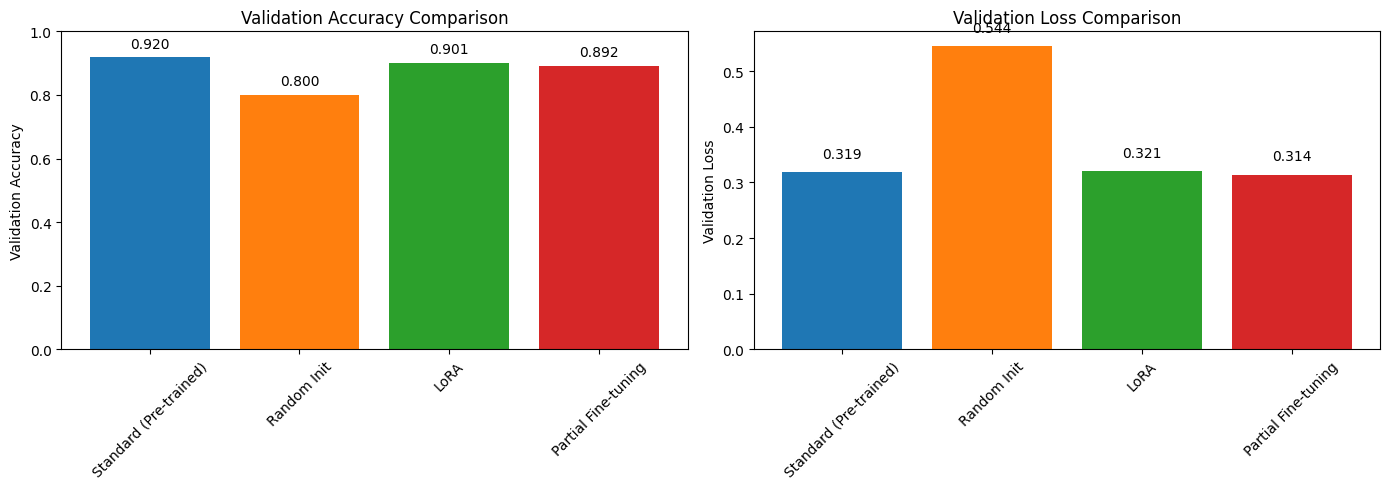


Figure saved as 'variant_comparison.png'

BEST PERFORMING VARIANT: Standard (Pre-trained)
Best Validation Accuracy: 0.9197


In [11]:
"""
BLOCK 11: Compare All Variants
Visualize and compare results from all fine-tuning approaches
"""

print("=" * 60)
print("COMPARISON OF ALL VARIANTS")
print("=" * 60)

# Compile all results
all_results = {
    "Standard (Pre-trained)": results_pretrained,
    "Random Init": results_random,
    "LoRA": results_lora,
    "Partial Fine-tuning": results_partial
}

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    "Variant": list(all_results.keys()),
    "Validation Accuracy": [r['eval_accuracy'] for r in all_results.values()],
    "Validation Loss": [r['eval_loss'] for r in all_results.values()],
})

print("\nResults Summary:")
print(comparison_df.to_string(index=False))

# Calculate improvements over random initialization
baseline_acc = results_random['eval_accuracy']
comparison_df['Improvement vs Random'] = comparison_df['Validation Accuracy'] - baseline_acc

print("\nImprovements over Random Initialization:")
print(comparison_df[['Variant', 'Improvement vs Random']].to_string(index=False))

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].bar(comparison_df['Variant'], comparison_df['Validation Accuracy'],
            color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Validation Accuracy Comparison')
axes[0].set_ylim([0, 1])
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['Validation Accuracy']):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

# Loss comparison
axes[1].bar(comparison_df['Variant'], comparison_df['Validation Loss'],
            color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Validation Loss Comparison')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['Validation Loss']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('variant_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'variant_comparison.png'")

# Best model
best_variant = comparison_df.loc[comparison_df['Validation Accuracy'].idxmax(), 'Variant']
best_accuracy = comparison_df['Validation Accuracy'].max()

print(f"\n{'=' * 60}")
print(f"BEST PERFORMING VARIANT: {best_variant}")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")
print(f"{'=' * 60}")

EVALUATION ON SELECTED 20 INSTANCES

Evaluating Standard Pre-trained model...
Evaluating Random Init model...
Evaluating LoRA model...
Evaluating Partial Fine-tuning model...

ACCURACY ON SELECTED INSTANCES

              Variant  Easy Accuracy  Difficult Accuracy  Overall Accuracy
Standard Pre-trained            0.9                 0.8              0.85
         Random Init            0.9                 0.8              0.85
                LoRA            1.0                 0.8              0.90
 Partial Fine-tuning            1.0                 0.8              0.90


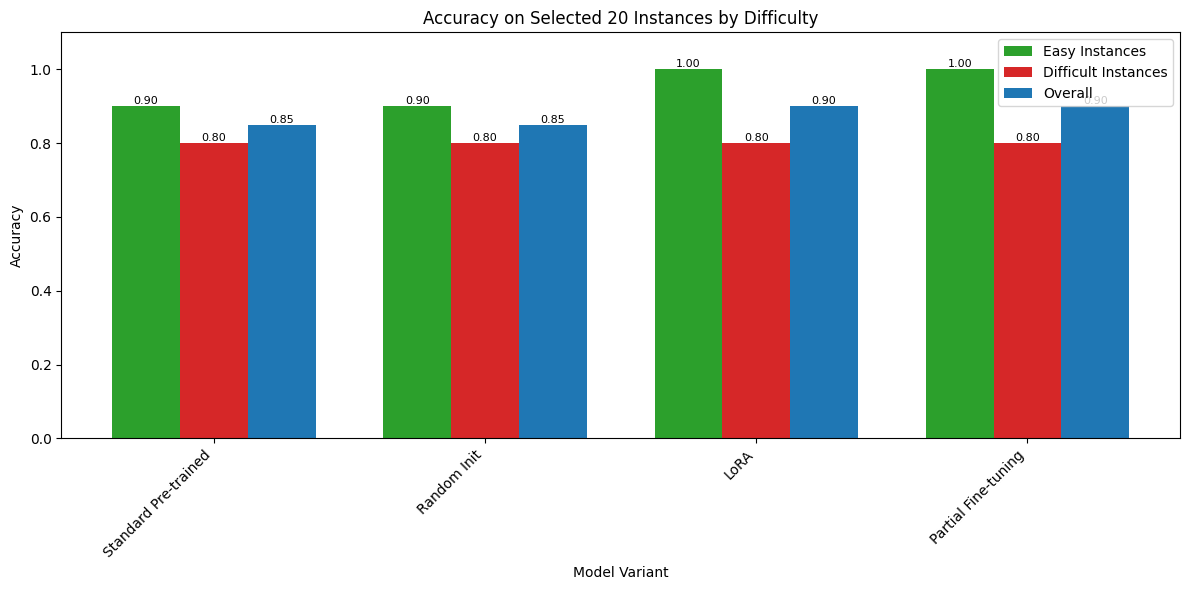


Figure saved as 'selected_instances_accuracy.png'


In [12]:
"""
BLOCK 12: Evaluate on Your 20 Selected Instances
Test each model variant on your easy and difficult instances
"""

print("=" * 60)
print("EVALUATION ON SELECTED 20 INSTANCES")
print("=" * 60)

def evaluate_on_instances(model, instances_df, variant_name):
    """Evaluate a model on specific instances"""
    model.eval()
    results = []

    with torch.no_grad():
        for idx, row in instances_df.iterrows():
            # Tokenize the sentence
            inputs = tokenizer(
                row['sentence'],
                return_tensors="pt",
                truncation=True,
                padding='max_length',
                max_length=128
            )

            # Move to device if using GPU
            if torch.cuda.is_available():
                inputs = {k: v.cuda() for k, v in inputs.items()}
                model = model.cuda()

            # Get prediction
            outputs = model(**inputs)
            logits = outputs.logits
            prediction = torch.argmax(logits, dim=-1).item()

            # Get confidence (probability)
            probs = torch.softmax(logits, dim=-1)
            confidence = probs[0, prediction].item()

            results.append({
                'idx': row['idx'],
                'sentence': row['sentence'],
                'true_label': row['label'],
                'predicted_label': prediction,
                'correct': prediction == row['label'],
                'confidence': confidence,
                'difficulty': row['difficulty']
            })

    return pd.DataFrame(results)

# Evaluate each variant
print("\nEvaluating Standard Pre-trained model...")
results_std_instances = evaluate_on_instances(
    trainer_pretrained.model, selected_df, "Standard Pre-trained"
)

print("Evaluating Random Init model...")
results_random_instances = evaluate_on_instances(
    trainer_random.model, selected_df, "Random Init"
)

print("Evaluating LoRA model...")
results_lora_instances = evaluate_on_instances(
    trainer_lora.model, selected_df, "LoRA"
)

print("Evaluating Partial Fine-tuning model...")
results_partial_instances = evaluate_on_instances(
    trainer_partial.model, selected_df, "Partial Fine-tuning"
)

# Calculate accuracy by difficulty
def calculate_accuracy_by_difficulty(results_df):
    easy_acc = results_df[results_df['difficulty'] == 'easy']['correct'].mean()
    difficult_acc = results_df[results_df['difficulty'] == 'difficult']['correct'].mean()
    overall_acc = results_df['correct'].mean()
    return {
        'easy': easy_acc,
        'difficult': difficult_acc,
        'overall': overall_acc
    }

print("\n" + "=" * 60)
print("ACCURACY ON SELECTED INSTANCES")
print("=" * 60)

variants_results = {
    "Standard Pre-trained": results_std_instances,
    "Random Init": results_random_instances,
    "LoRA": results_lora_instances,
    "Partial Fine-tuning": results_partial_instances
}

summary_data = []
for variant_name, results_df in variants_results.items():
    acc_by_diff = calculate_accuracy_by_difficulty(results_df)
    summary_data.append({
        'Variant': variant_name,
        'Easy Accuracy': acc_by_diff['easy'],
        'Difficult Accuracy': acc_by_diff['difficult'],
        'Overall Accuracy': acc_by_diff['overall']
    })

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(summary_df))
width = 0.25

bars1 = ax.bar(x - width, summary_df['Easy Accuracy'], width,
               label='Easy Instances', color='#2ca02c')
bars2 = ax.bar(x, summary_df['Difficult Accuracy'], width,
               label='Difficult Instances', color='#d62728')
bars3 = ax.bar(x + width, summary_df['Overall Accuracy'], width,
               label='Overall', color='#1f77b4')

ax.set_xlabel('Model Variant')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy on Selected 20 Instances by Difficulty')
ax.set_xticks(x)
ax.set_xticklabels(summary_df['Variant'], rotation=45, ha='right')
ax.legend()
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('selected_instances_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved as 'selected_instances_accuracy.png'")

In [13]:
"""
BLOCK 13: Detailed Instance-Level Analysis
Examine which specific instances each model gets right/wrong
"""

print("=" * 60)
print("DETAILED INSTANCE-LEVEL ANALYSIS")
print("=" * 60)

# Compare predictions across all models
comparison_instances = selected_df.copy()

# Add predictions from each model
comparison_instances['std_pred'] = results_std_instances['predicted_label']
comparison_instances['std_correct'] = results_std_instances['correct']
comparison_instances['rand_pred'] = results_random_instances['predicted_label']
comparison_instances['rand_correct'] = results_random_instances['correct']
comparison_instances['lora_pred'] = results_lora_instances['predicted_label']
comparison_instances['lora_correct'] = results_lora_instances['correct']
comparison_instances['partial_pred'] = results_partial_instances['predicted_label']
comparison_instances['partial_correct'] = results_partial_instances['correct']

# Count how many models got each instance correct
comparison_instances['models_correct'] = (
    comparison_instances['std_correct'].astype(int) +
    comparison_instances['rand_correct'].astype(int) +
    comparison_instances['lora_correct'].astype(int) +
    comparison_instances['partial_correct'].astype(int)
)

print("\n--- Instances All Models Got Correct ---")
all_correct = comparison_instances[comparison_instances['models_correct'] == 4]
print(f"Count: {len(all_correct)}")
if len(all_correct) > 0:
    print(all_correct[['sentence', 'label', 'difficulty']])

print("\n--- Instances All Models Got Wrong ---")
all_wrong = comparison_instances[comparison_instances['models_correct'] == 0]
print(f"Count: {len(all_wrong)}")
if len(all_wrong) > 0:
    print(all_wrong[['sentence', 'label', 'difficulty']])

print("\n--- Instances with Mixed Results ---")
mixed = comparison_instances[(comparison_instances['models_correct'] > 0) &
                             (comparison_instances['models_correct'] < 4)]
print(f"Count: {len(mixed)}")
if len(mixed) > 0:
    print(mixed[['sentence', 'label', 'difficulty', 'models_correct']])

# Analyze easy vs difficult instances
print("\n" + "=" * 60)
print("EASY VS DIFFICULT INSTANCE ANALYSIS")
print("=" * 60)

for difficulty in ['easy', 'difficult']:
    subset = comparison_instances[comparison_instances['difficulty'] == difficulty]
    print(f"\n{difficulty.upper()} Instances ({len(subset)} total):")
    print(f"  All models correct: {len(subset[subset['models_correct'] == 4])}")
    print(f"  3 models correct: {len(subset[subset['models_correct'] == 3])}")
    print(f"  2 models correct: {len(subset[subset['models_correct'] == 2])}")
    print(f"  1 model correct: {len(subset[subset['models_correct'] == 1])}")
    print(f"  All models wrong: {len(subset[subset['models_correct'] == 0])}")

# Show specific examples of challenging instances
print("\n" + "=" * 60)
print("MOST CHALLENGING INSTANCES (All models wrong)")
print("=" * 60)

if len(all_wrong) > 0:
    for idx, row in all_wrong.iterrows():
        print(f"\nInstance {row['idx']}:")
        print(f"  Sentence: '{row['sentence']}'")
        print(f"  True label: {row['label']}")
        print(f"  Difficulty: {row['difficulty']}")
        print(f"  Predictions:")
        print(f"    Standard: {row['std_pred']}")
        print(f"    Random: {row['rand_pred']}")
        print(f"    LoRA: {row['lora_pred']}")
        print(f"    Partial: {row['partial_pred']}")

# Show instances where pre-training helped most
print("\n" + "=" * 60)
print("INSTANCES WHERE PRE-TRAINING HELPED")
print("=" * 60)

# Instances that pretrained got right but random got wrong
pretrain_helps = comparison_instances[
    (comparison_instances['std_correct'] == True) &
    (comparison_instances['rand_correct'] == False)
]

print(f"\nInstances where pre-trained succeeded but random init failed: {len(pretrain_helps)}")
if len(pretrain_helps) > 0:
    print(pretrain_helps[['sentence', 'label', 'difficulty']].head(5))

# Save detailed results to CSV
comparison_instances.to_csv('detailed_instance_results.csv', index=False)
print("\n\nDetailed results saved to 'detailed_instance_results.csv'")

DETAILED INSTANCE-LEVEL ANALYSIS

--- Instances All Models Got Correct ---
Count: 13
                                             sentence  label difficulty
0                           This is a terrible movie.      0       easy
1                               Absolutely brilliant!      1       easy
3                             Boring and predictable.      0       easy
4                           A complete waste of time.      0       easy
5                          The best film of the year.      1       easy
7                           Wonderfully entertaining.      1       easy
8                               Total disappointment.      0       easy
9                             Fantastic performances.      1       easy
10                     Not the worst movie I've seen.      0  difficult
12  The first half was great, but the ending ruine...      0  difficult
13                            Could have been better.      0  difficult
14                I expected more from this directo

In [14]:
"""
BLOCK 14: Generate Report Summary
Create a summary of findings for your report
"""

print("=" * 80)
print("DELIVERABLE 2 - SUMMARY FOR REPORT")
print("=" * 80)

print("\n1. MODELS TRAINED:")
print("   - Variant 1: Standard fine-tuning (pre-trained GPT-2)")
print("   - Variant 2: Random initialization (no pre-training)")
print("   - Variant 3: LoRA fine-tuning")
print("   - Variant 4: Partial fine-tuning (freeze early layers)")

print("\n2. OVERALL VALIDATION ACCURACY:")
for variant, result in all_results.items():
    print(f"   {variant}: {result['eval_accuracy']:.4f}")

print("\n3. ACCURACY ON SELECTED 20 INSTANCES:")
print(summary_df.to_string(index=False))

print("\n4. KEY FINDINGS:")

# Finding 1: Impact of pre-training
pretrain_improvement = results_pretrained['eval_accuracy'] - results_random['eval_accuracy']
print(f"\n   a) Impact of Pre-training:")
print(f"      - Pre-training improves accuracy by {pretrain_improvement:.4f}")
print(f"      - Pre-trained model: {results_pretrained['eval_accuracy']:.4f}")
print(f"      - Random init model: {results_random['eval_accuracy']:.4f}")

# Finding 2: Parameter efficiency
print(f"\n   b) Parameter Efficiency:")
print(f"      - LoRA achieves {results_lora['eval_accuracy']:.4f} accuracy")
print(f"      - Uses significantly fewer trainable parameters")
print(f"      - Comparable to standard fine-tuning: {results_pretrained['eval_accuracy']:.4f}")

# Finding 3: Easy vs difficult instances
print(f"\n   c) Easy vs Difficult Instances:")
for idx, row in summary_df.iterrows():
    easy_diff = row['Easy Accuracy'] - row['Difficult Accuracy']
    print(f"      - {row['Variant']}:")
    print(f"        Easy: {row['Easy Accuracy']:.2f}, Difficult: {row['Difficult Accuracy']:.2f}")
    print(f"        Gap: {easy_diff:.2f}")

# Finding 4: Instance-level analysis
print(f"\n   d) Instance-Level Analysis:")
print(f"      - Instances all models got correct: {len(all_correct)}/20")
print(f"      - Instances all models got wrong: {len(all_wrong)}/20")
print(f"      - These challenging instances reveal model limitations")

# Finding 5: Best model
print(f"\n   e) Best Performing Model:")
print(f"      - {best_variant} with {best_accuracy:.4f} accuracy")

print("\n5. RECOMMENDATIONS FOR REPORT:")
print("""
   - Discuss why pre-training matters (transfer learning)
   - Analyze the trade-off between parameter efficiency and performance
   - Examine which linguistic phenomena make instances difficult
   - Consider why certain instances fool all models
   - Reflect on the value of different fine-tuning strategies
""")

print("\n6. FILES GENERATED:")
print("   - variant_comparison.png (comparison chart)")
print("   - selected_instances_accuracy.png (accuracy by difficulty)")
print("   - detailed_instance_results.csv (full instance-level data)")

print("\n" + "=" * 80)
print("DELIVERABLE 2 COMPLETE!")
print("=" * 80)

print("\nNext steps:")
print("1. Review all outputs and visualizations")
print("2. Write your analysis in the report")
print("3. Include code snippets and results")
print("4. Reflect on what you learned")

DELIVERABLE 2 - SUMMARY FOR REPORT

1. MODELS TRAINED:
   - Variant 1: Standard fine-tuning (pre-trained GPT-2)
   - Variant 2: Random initialization (no pre-training)
   - Variant 3: LoRA fine-tuning
   - Variant 4: Partial fine-tuning (freeze early layers)

2. OVERALL VALIDATION ACCURACY:
   Standard (Pre-trained): 0.9197
   Random Init: 0.8005
   LoRA: 0.9014
   Partial Fine-tuning: 0.8922

3. ACCURACY ON SELECTED 20 INSTANCES:
             Variant  Easy Accuracy  Difficult Accuracy  Overall Accuracy
Standard Pre-trained            0.9                 0.8              0.85
         Random Init            0.9                 0.8              0.85
                LoRA            1.0                 0.8              0.90
 Partial Fine-tuning            1.0                 0.8              0.90

4. KEY FINDINGS:

   a) Impact of Pre-training:
      - Pre-training improves accuracy by 0.1193
      - Pre-trained model: 0.9197
      - Random init model: 0.8005

   b) Parameter Efficiency:
